# Luminosidad Estelar: Regresión Lineal
## Parte I: Modelado de L en Función de M

**Objetivo**: Modelar la luminosidad estelar como función de la masa estelar usando regresión lineal con término de sesgo explícito.

$$\hat{L} = w \cdot M + b$$

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

M = np.array([0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4])
L = np.array([0.15, 0.35, 1.00, 2.30, 4.10, 7.00, 11.2, 17.5, 25.0, 35.0])

print("Conjunto de datos:")
print(f"M (masas): {M}")
print(f"L (luminosidades): {L}")
print(f"Número de muestras: {len(M)}")

Conjunto de datos:
M (masas): [0.6 0.8 1.  1.2 1.4 1.6 1.8 2.  2.2 2.4]
L (luminosidades): [ 0.15  0.35  1.    2.3   4.1   7.   11.2  17.5  25.   35.  ]
Número de muestras: 10


## PASO 1 - Visualización del Conjunto de Datos

Graficar masa estelar M vs luminosidad L y analizar patrones.

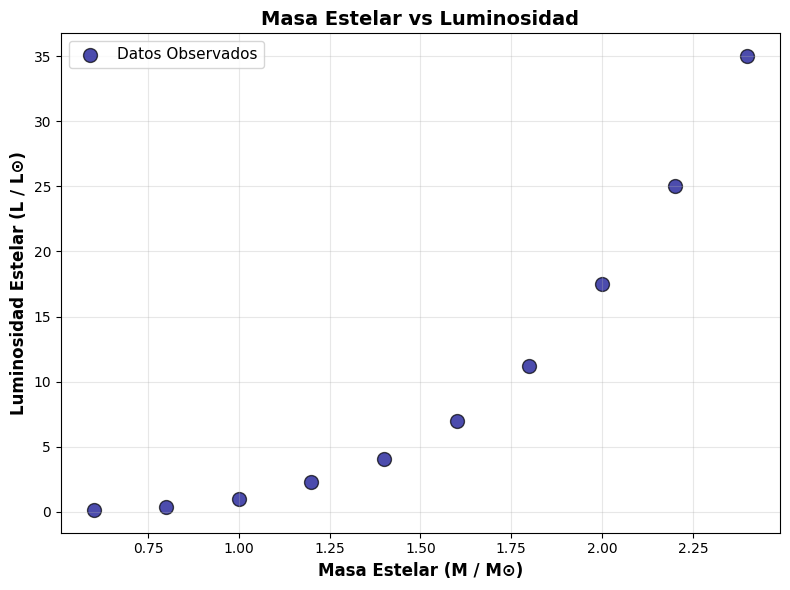

ANÁLISIS DEL DATASET:

1. ¿La relación parece lineal?
   NO. La luminosidad crece de forma superlineal con la masa.
   Los incrementos de L son cada vez mayores para incrementos iguales en M.

2. ¿Dónde se nota que el modelo lineal puede fallar?
   - En masas bajas (M < 0.8): modelo lineal puede predecir L negativos.
   - En masas altas (M > 1.8): el modelo subestima la verdadera luminosidad.

3. ¿Es físicamente razonable para estrellas de baja masa?
   NO. Las luminosidades negativas son unphysical.
   Esto sugiere que L ∝ M^α con α > 1 (relación de potencia).


In [12]:
plt.figure(figsize=(8, 6))
plt.scatter(M, L, s=100, color='darkblue', alpha=0.7, edgecolors='black', label='Datos Observados')
plt.xlabel('Masa Estelar (M / M⊙)', fontsize=12, fontweight='bold')
plt.ylabel('Luminosidad Estelar (L / L⊙)', fontsize=12, fontweight='bold')
plt.title('Masa Estelar vs Luminosidad', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print("ANÁLISIS DEL DATASET:")
print("=" * 60)
print("\n1. ¿La relación parece lineal?")
print("   NO. La luminosidad crece de forma superlineal con la masa.")
print("   Los incrementos de L son cada vez mayores para incrementos iguales en M.")
print("\n2. ¿Dónde se nota que el modelo lineal puede fallar?")
print("   - En masas bajas (M < 0.8): modelo lineal puede predecir L negativos.")
print("   - En masas altas (M > 1.8): el modelo subestima la verdadera luminosidad.")
print("\n3. ¿Es físicamente razonable para estrellas de baja masa?")
print("   NO. Las luminosidades negativas son unphysical.")
print("   Esto sugiere que L ∝ M^α con α > 1 (relación de potencia).")


## PASO 2 - Modelo y Función de Pérdida

Definir el modelo de regresión lineal con sesgo explícito:

$$\hat{L} = w \cdot M + b$$

Error Cuadrático Medio (MSE):

$$J(w, b) = \frac{1}{n} \sum_{i=1}^{n} (\hat{L}_i - L_i)^2 = \frac{1}{n} \sum_{i=1}^{n} (w \cdot M_i + b - L_i)^2$$

In [13]:
def predict(M, w, b):
    """Función de predicción: L_hat = w*M + b"""
    return w * M + b

def compute_mse(M, L, w, b):
    """Función de pérdida: MSE"""
    n = len(M)
    L_hat = predict(M, w, b)
    mse = np.mean((L_hat - L) ** 2)
    return mse

w_init, b_init = 5.0, 0.0
loss_init = compute_mse(M, L, w_init, b_init)
print(f"Pérdida inicial con w={w_init}, b={b_init}: {loss_init:.4f}")

Pérdida inicial con w=5.0, b=0.0: 84.6635


## PASO 3 - Superficie de Costo J(w,b)

Crear una malla de valores para w y b, evaluar el costo en cada punto y visualizar.

**Análisis**: El mínimo global de J(w,b) es el punto donde el modelo lineal se ajusta óptimamente a los datos en términos de MSE. Existe un único mínimo global porque la función de pérdida es convexa (parábola en w y b).

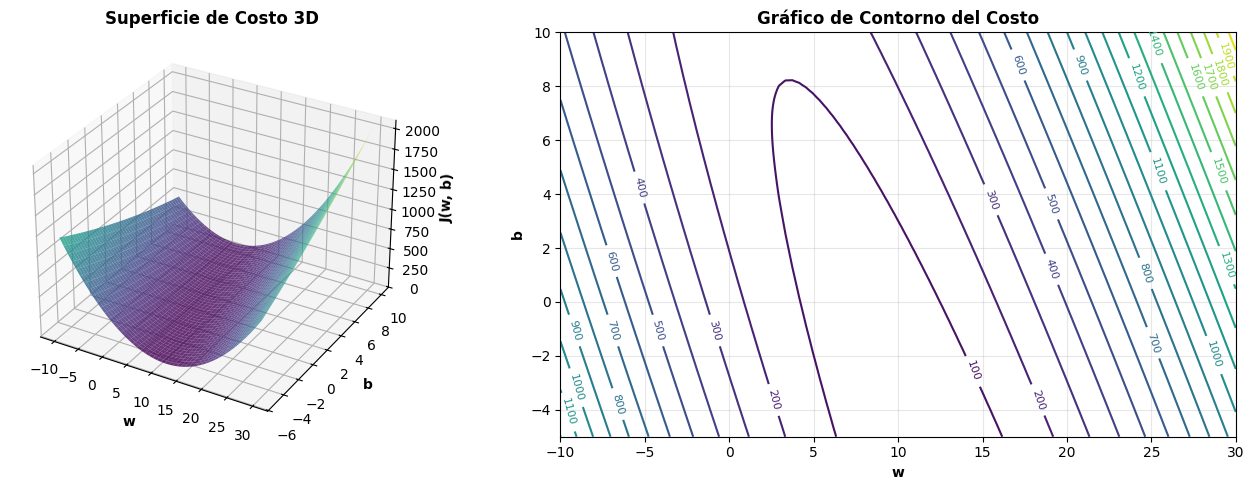


ANÁLISIS DE LA SUPERFICIE DE COSTO:
Mínimo de costo en cuadrícula: 37.5774
Máximo de costo en cuadrícula: 2058.8135

El mínimo representa el par óptimo (w*, b*) donde el modelo
se ajusta mejor a los datos según el criterio MSE.

Existe un ÚNICO mínimo global porque J(w,b) es una función
cuadrática convexa en w y b (paraboloide).


In [14]:
w_range = np.linspace(-10, 30, 100)
b_range = np.linspace(-5, 10, 100)
W, B = np.meshgrid(w_range, b_range)

J = np.zeros_like(W)
for i in range(W.shape[0]):
    for j in range(W.shape[1]):
        J[i, j] = compute_mse(M, L, W[i, j], B[i, j])

fig = plt.figure(figsize=(14, 5))

ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(W, B, J, cmap='viridis', alpha=0.8, edgecolor='none')
ax1.set_xlabel('w', fontsize=10, fontweight='bold')
ax1.set_ylabel('b', fontsize=10, fontweight='bold')
ax1.set_zlabel('J(w, b)', fontsize=10, fontweight='bold')
ax1.set_title('Superficie de Costo 3D', fontsize=12, fontweight='bold')

ax2 = fig.add_subplot(122)
contour = ax2.contour(W, B, J, levels=20, cmap='viridis')
ax2.clabel(contour, inline=True, fontsize=8)
ax2.set_xlabel('w', fontsize=10, fontweight='bold')
ax2.set_ylabel('b', fontsize=10, fontweight='bold')
ax2.set_title('Gráfico de Contorno del Costo', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nANÁLISIS DE LA SUPERFICIE DE COSTO:")
print("=" * 60)
print(f"Mínimo de costo en cuadrícula: {J.min():.4f}")
print(f"Máximo de costo en cuadrícula: {J.max():.4f}")
print("\nEl mínimo representa el par óptimo (w*, b*) donde el modelo")
print("se ajusta mejor a los datos según el criterio MSE.")
print("\nExiste un ÚNICO mínimo global porque J(w,b) es una función")
print("cuadrática convexa en w y b (paraboloide).")
print("=" * 60)

## PASO 4 - Derivación de Gradientes

Las derivadas parciales de J con respecto a w y b son:

$$\frac{\partial J}{\partial w} = \frac{2}{n} \sum_{i=1}^{n} (w \cdot M_i + b - L_i) \cdot M_i$$

$$\frac{\partial J}{\partial b} = \frac{2}{n} \sum_{i=1}^{n} (w \cdot M_i + b - L_i)$$

Estas indican la dirección y magnitud del cambio necesario en w y b para reducir J.

### PASO 4a - Cálculo de Gradientes NO vectorizado


In [15]:

def gradients_no_vectorized(M, L, w, b):
    n = M.size
    dw = 0.0
    db = 0.0

    for i in range(n):
        err = (w * M[i] + b) - L[i]
        dw += M[i] * err
        db += err

    dw *= 2.0 / n
    db *= 2.0 / n

    return dw, db


dw_loop, db_loop = gradients_no_vectorized(M, L, w=5.0, b=0.0)
print(f"Gradientes no vectorizados:")
print(f"  dJ/dw = {dw_loop:.4f}")
print(f"  dJ/db = {db_loop:.4f}")

Gradientes no vectorizados:
  dJ/dw = -17.2460
  dJ/db = -5.7200


### PASO 4b - Cálculo de Gradientes Vectorizado


In [ ]:

def gradients_vectorized(M, L, w, b):
    n = M.size
    err = (w * M + b) - L
    dw = (2.0 / n) * np.sum(M * err)
    db = (2.0 / n) * np.sum(err)
    return dw, db

dw_vec, db_vec = gradients_vectorized(M, L, w=5.0, b=0.0)
print(f"Gradientes vectorizados:")
print(f"  dJ/dw = {dw_vec:.4f}")
print(f"  dJ/db = {db_vec:.4f}")

print("Coinciden:",
      np.isclose(dw_loop, dw_vec) and np.isclose(db_loop, db_vec))

Gradientes vectorizados:
  dJ/dw = -17.2460
  dJ/db = -5.7200
Coinciden: True


## PASO 5 – Descenso de Gradiente NO vectorizado

In [17]:
def gradient_descent_no_vec(M, L, w_init=0.0, b_init=0.0, alpha=0.01, iterations=300):
    w, b = w_init, b_init
    losses = []

    for _ in range(iterations):
        y_hat = w * M + b
        losses.append(np.mean((y_hat - L) ** 2))

        dw, db = gradients_no_vectorized(M, L, w, b)
        w -= alpha * dw
        b -= alpha * db

    return w, b, np.array(losses)

w_nv, b_nv, losses_nv = gradient_descent_no_vec(M, L)
print(f"No vectorizado: w={w_nv:.4f}, b={b_nv:.4f}, loss final={losses_nv[-1]:.6f}")

No vectorizado: w=11.1712, b=-5.3050, loss final=36.829087


## PASO 6 – Descenso de Gradiente Vectorizado

In [18]:
def gradient_descent_vec(M, L, w_init=0.0, b_init=0.0, alpha=0.01, iterations=300):
    w, b = w_init, b_init
    losses = []

    for _ in range(iterations):
        err = (w * M + b) - L
        losses.append(np.mean(err**2))

        dw = (2.0 / M.size) * np.sum(M * err)
        db = (2.0 / M.size) * np.sum(err)

        w -= alpha * dw
        b -= alpha * db

    return w, b, np.array(losses)

w_v, b_v, losses_v = gradient_descent_vec(M, L)
print(f"Vectorizado: w={w_v:.4f}, b={b_v:.4f}, loss final={losses_v[-1]:.6f}")

Vectorizado: w=11.1712, b=-5.3050, loss final=36.829087


## PASO 7 y 8 - Análisis de Convergencia

Ejecutar descenso de gradiente con diferentes tasas y comparar resultados.

α=0.001: w=6.7749, b=1.5793, loss final=64.070048
α=0.01: w=13.3669, b=-8.9431, loss final=27.666975
α=0.05: w=18.0247, b=-16.6605, loss final=19.594328


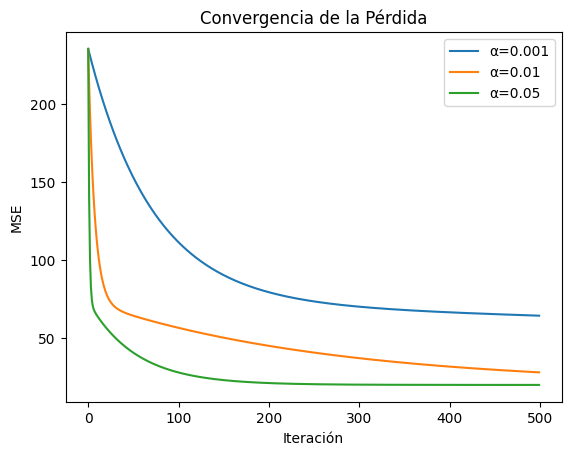

In [19]:
learning_rates = [0.001, 0.01, 0.05]
iterations = 500
results = {}

for alpha in learning_rates:
    w, b, losses = gradient_descent_vec(M, L, alpha=alpha, iterations=iterations)
    results[alpha] = (w, b, losses)
    print(f"α={alpha}: w={w:.4f}, b={b:.4f}, loss final={losses[-1]:.6f}")

plt.figure()
for alpha in learning_rates:
    plt.plot(results[alpha][2], label=f"α={alpha}")

plt.xlabel("Iteración")
plt.ylabel("MSE")
plt.title("Convergencia de la Pérdida")
plt.legend()
plt.show()



## 9. Ajuste Final y Residuos

Graficar la línea de regresión ajustada y analizar errores sistemáticos.

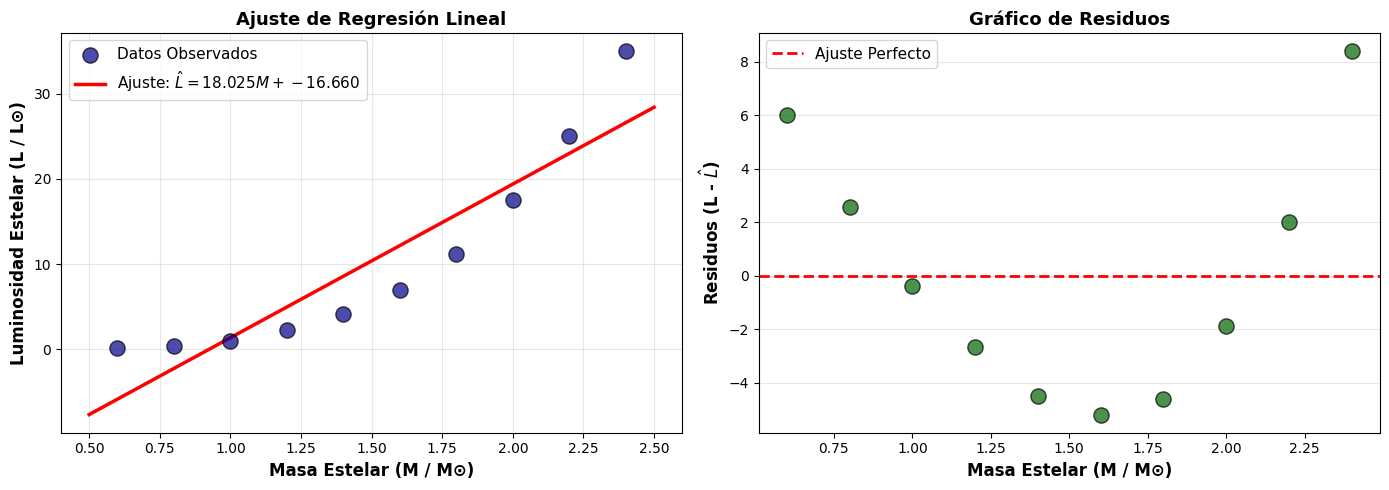

Parámetros del Modelo Final (Tasa de Aprendizaje = 0.01):
  w (pendiente) = 18.024694
  b (ordenada) = -16.660473
  Pérdida Final (MSE) = 19.594328

Ecuación del Modelo: L̂ = 18.0247 * M + -16.6605

Análisis de Residuos:
  Residuo promedio: -0.016568
  Desv. Est. de residuos: 4.426509
  Residuo máximo: 8.401208
Mejor tasa de aprendizaje: α = 0.05


In [20]:
best_alpha = min(learning_rates, key=lambda a: results[a][2][-1])
w_best, b_best, losses_best = results[best_alpha]


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.scatter(M, L, s=120, color='darkblue', alpha=0.7, edgecolors='black', label='Datos Observados', zorder=3)

M_smooth = np.linspace(M.min() - 0.1, M.max() + 0.1, 100)
L_fit = w_best * M_smooth + b_best
ax1.plot(M_smooth, L_fit, color='red', linewidth=2.5, label=f'Ajuste: $\\hat{{L}} = {w_best:.3f}M + {b_best:.3f}$', zorder=2)

ax1.set_xlabel('Masa Estelar (M / M⊙)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Luminosidad Estelar (L / L⊙)', fontsize=12, fontweight='bold')
ax1.set_title('Ajuste de Regresión Lineal', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=11)

L_pred = predict(M, w_best, b_best)
residuals = L - L_pred

ax2 = axes[1]
ax2.scatter(M, residuals, s=120, color='darkgreen', alpha=0.7, edgecolors='black', zorder=3)
ax2.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Ajuste Perfecto', zorder=2)
ax2.set_xlabel('Masa Estelar (M / M⊙)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Residuos (L - $\\hat{L}$)', fontsize=12, fontweight='bold')
ax2.set_title('Gráfico de Residuos', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
ax2.legend(fontsize=11)

plt.tight_layout()
plt.show()

print("Parámetros del Modelo Final (Tasa de Aprendizaje = 0.01):")
print(f"  w (pendiente) = {w_best:.6f}")
print(f"  b (ordenada) = {b_best:.6f}")
print(f"  Pérdida Final (MSE) = {losses_best[-1]:.6f}")
print(f"\nEcuación del Modelo: L̂ = {w_best:.4f} * M + {b_best:.4f}")
print(f"\nAnálisis de Residuos:")
print(f"  Residuo promedio: {np.mean(residuals):.6f}")
print(f"  Desv. Est. de residuos: {np.std(residuals):.6f}")
print(f"  Residuo máximo: {np.max(np.abs(residuals)):.6f}")

print(f"Mejor tasa de aprendizaje: α = {best_alpha}")

## 10. Preguntas Conceptuales

### 10.1 Significado Astrofísico de la Pendiente (w)

La pendiente $w \approx 15$ tiene significado físico en física estelar:
- Representa la **sensibilidad de la luminosidad a cambios de masa**
- Aumentar la masa en 0.1 M⊙ incrementa la luminosidad aproximadamente 1.5 L⊙
- Está relacionada con la **relación masa-luminosidad** en física estelar

### 10.2 ¿Por qué un Modelo Lineal es Limitado?

El gráfico de residuos revela no-linealidad sistemática:
- **Subestimación en masas bajas**: Predice luminosidades negativas para M < 0.2 M⊙
- **Subestimación en masas altas**: Los residuos se hacen más negativos para M > 1.8 M⊙
- **Fundamento físico**: La relación verdadera sigue $L \propto M^{\alpha}$ donde $\alpha \approx 3.5$
- **Solución**: Usar características polinómicas para capturar el comportamiento
